# Unified DOA Benchmark

This notebook merges the stronger pieces of `test copy.py` and `snn_ssl_signle.ipynb` into a more research-oriented benchmark.

It uses:
- active-speech cropping and 4-microphone spatialization from `test copy.py`
- lambda sweeps, clean/noisy evaluation, and multi-model comparisons inspired by `snn_ssl_signle.ipynb`
- explicit `soundfile` waveform loading instead of `torchaudio.load` compatibility patching
- per-seed deterministic synthetic datasets with optional lazy caching to avoid recomputing fixed features every epoch

Models compared in one pipeline:
- `ConvRecSNN`: convolutional recurrent SNN adapted from `test copy.py`
- `FlatLIFSNN`: notebook-style stacked LIF SNN on flattened frame features
- `CRNNBaseline`: convolution + bidirectional GRU baseline
- `GCCPHATLSBaseline`: simple GCC-PHAT + least-squares baseline on averaged pairwise cues

The workflow is:
1. Build per-seed train/val/test splits from SpeechCommands.
2. Synthesize 4-microphone mixtures with DOA labels and extract `log-mel + GCC-PHAT` features.
3. Train multiple seeds and multiple lambdas for both SNNs, plus CRNN and classical baseline.
4. Select the best setting using aggregated validation metrics only, then report clean/noisy test metrics.

In [15]:
import copy
import json
import math
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


@dataclass
class ExpConfig:
    seed: int = 274
    data_root: str = "./data_sc"
    speech_version: str = "speech_commands_v0.02"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    amp: bool = True

    sample_rate: int = 16000
    audio_channels: int = 4
    window_seconds: float = 0.32
    doa_bins: int = 36
    pred_tol_bins: int = 1

    n_fft: int = 512
    win_length: int = 400
    hop_length: int = 160
    n_mels: int = 48

    train_samples: int = 4000 if torch.cuda.is_available() else 800
    val_samples: int = 800 if torch.cuda.is_available() else 200
    test_samples: int = 800 if torch.cuda.is_available() else 200
    epochs: int = 6 if torch.cuda.is_available() else 2
    batch_size: int = 64 if torch.cuda.is_available() else 16
    num_workers: int = 0
    cache_samples: bool = True
    run_seeds: Tuple[int, ...] = (274, 275, 276) if torch.cuda.is_available() else (274, 275)
    lr: float = 2e-3
    weight_decay: float = 1e-4
    lambdas: Tuple[float, ...] = (0.0, 3e-2, 1e-1, 3e-1, 1.0)
    label_smoothing: float = 0.05

    train_noise_prob: float = 0.6
    val_noise_prob: float = 0.0
    test_noisy_prob: float = 1.0
    noise_snr_db_min: float = 5.0
    noise_snr_db_max: float = 20.0
    temporal_dropout_prob: float = 0.3
    temporal_dropout_ratio: float = 0.05
    amplitude_jitter_min: float = 0.8
    amplitude_jitter_max: float = 1.2

    conv1_channels: int = 32
    conv2_channels: int = 64
    hidden_size: int = 192
    flat_hidden_size: int = 128
    crnn_hidden_size: int = 128
    beta: float = 0.95
    threshold: float = 1.0
    dropout: float = 0.1

    mic_radius: float = 0.04
    speed_of_sound: float = 343.0
    output_dir: str = "./runs/unified_doa_notebook"

    @property
    def device_type(self) -> str:
        return "cuda" if self.device.startswith("cuda") else "cpu"

    @property
    def pin_memory(self) -> bool:
        return self.device_type == "cuda"

    @property
    def cache_enabled(self) -> bool:
        return self.cache_samples and self.num_workers == 0

    @property
    def window_samples(self) -> int:
        return int(round(self.window_seconds * self.sample_rate))

    @property
    def feature_frames(self) -> int:
        return self.window_samples // self.hop_length + 1

    @property
    def input_channels(self) -> int:
        pairs = self.audio_channels * (self.audio_channels - 1) // 2
        return self.audio_channels + pairs

    @property
    def bin_width_rad(self) -> float:
        return 2.0 * math.pi / self.doa_bins


print("torch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)
print("soundfile:", sf.__libsndfile_version__)
print("device:", "cuda" if torch.cuda.is_available() else "cpu")

torch: 2.8.0+cu128
torchaudio: 2.8.0+cpu
soundfile: 1.2.2
device: cuda


In [16]:
FEATURE_CACHE: Dict[Tuple[int, int, int, int], Tuple[torch.Tensor, torch.Tensor]] = {}
ANGLE_CACHE: Dict[int, torch.Tensor] = {}
PAIR_GEOMETRY_CACHE: Dict[Tuple[int, float], torch.Tensor] = {}


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def load_waveform(path: Path) -> Tuple[torch.Tensor, int]:
    audio, sample_rate = sf.read(str(path), dtype="float32", always_2d=True)
    waveform = torch.from_numpy(np.ascontiguousarray(audio.T))
    return waveform, int(sample_rate)


def pad_or_trim(x: torch.Tensor, target: int, dim: int = -1) -> torch.Tensor:
    if x.shape[dim] == target:
        return x
    if x.shape[dim] > target:
        return x.narrow(dim, 0, target)
    shape = list(x.shape)
    shape[dim] = target - x.shape[dim]
    return torch.cat([x, x.new_zeros(shape)], dim=dim)


def feature_kernels(cfg: ExpConfig) -> Tuple[torch.Tensor, torch.Tensor]:
    key = (cfg.sample_rate, cfg.n_fft, cfg.win_length, cfg.n_mels)
    if key not in FEATURE_CACHE:
        window = torch.hann_window(cfg.win_length)
        mel_fb = torchaudio.functional.melscale_fbanks(
            n_freqs=cfg.n_fft // 2 + 1,
            f_min=0.0,
            f_max=cfg.sample_rate / 2.0,
            n_mels=cfg.n_mels,
            sample_rate=cfg.sample_rate,
        ).float()
        FEATURE_CACHE[key] = (window, mel_fb)
    return FEATURE_CACHE[key]


def extract_features(audio: torch.Tensor, cfg: ExpConfig) -> torch.Tensor:
    window, mel_fb = feature_kernels(cfg)
    stft = torch.stft(
        audio,
        n_fft=cfg.n_fft,
        hop_length=cfg.hop_length,
        win_length=cfg.win_length,
        window=window,
        return_complex=True,
    )
    power = stft.abs().pow(2.0)
    mel = torch.einsum("fm,cft->cmt", mel_fb, power).clamp_min(1e-10)
    log_mel = (10.0 * torch.log10(mel)).transpose(1, 2)
    log_mel = (log_mel - log_mel.mean(dim=(1, 2), keepdim=True)) / log_mel.std(
        dim=(1, 2), keepdim=True
    ).clamp_min(1e-5)

    gcc_parts = []
    half = cfg.n_mels // 2
    for m in range(cfg.audio_channels):
        for n in range(m + 1, cfg.audio_channels):
            cross = stft[m].conj() * stft[n]
            phat = cross / cross.abs().clamp_min(1e-6)
            cc = torch.fft.irfft(phat, n=cfg.n_fft, dim=0)
            cc = torch.cat([cc[-half:], cc[:half]], dim=0).transpose(0, 1)
            gcc_parts.append(cc)
    gcc = torch.stack(gcc_parts, dim=0)
    gcc = (gcc - gcc.mean(dim=(1, 2), keepdim=True)) / gcc.std(
        dim=(1, 2), keepdim=True
    ).clamp_min(1e-5)

    feat = torch.cat([log_mel, gcc], dim=0)
    return pad_or_trim(feat, cfg.feature_frames, dim=1).contiguous()


def mic_positions(cfg: ExpConfig) -> np.ndarray:
    r = cfg.mic_radius
    return np.array([[r, 0.0], [0.0, r], [-r, 0.0], [0.0, -r]], dtype=np.float32)


def bin_centers(cfg: ExpConfig, device: Optional[torch.device] = None) -> torch.Tensor:
    if cfg.doa_bins not in ANGLE_CACHE:
        centers = torch.linspace(-math.pi, math.pi, cfg.doa_bins + 1)[:-1] + 0.5 * cfg.bin_width_rad
        ANGLE_CACHE[cfg.doa_bins] = centers
    centers = ANGLE_CACHE[cfg.doa_bins]
    return centers if device is None else centers.to(device)


def apply_fractional_delay(signal: np.ndarray, delay_s: float, sample_rate: int) -> np.ndarray:
    freqs = np.fft.rfftfreq(signal.shape[0], d=1.0 / sample_rate)
    phase = np.exp(-2j * math.pi * freqs * delay_s)
    shifted = np.fft.irfft(np.fft.rfft(signal) * phase, n=signal.shape[0])
    return shifted.astype(np.float32)


def crop_active_speech(
    waveform: torch.Tensor,
    sample_rate: int,
    rng: np.random.Generator,
    cfg: ExpConfig,
) -> torch.Tensor:
    x = waveform.mean(dim=0).float()
    if sample_rate != cfg.sample_rate:
        x = torchaudio.functional.resample(x, sample_rate, cfg.sample_rate)

    x = x - x.mean()
    peak = x.abs().amax()
    if peak > 0:
        x = x / peak

    if peak > 0:
        mask = x.abs() > 0.05
        if mask.any():
            idx = mask.nonzero(as_tuple=False).squeeze(1)
            margin = max(1, cfg.sample_rate // 50)
            left = max(0, int(idx[0]) - margin)
            right = min(x.numel(), int(idx[-1]) + 1 + margin)
            x = x[left:right]

    if x.numel() <= cfg.window_samples:
        pad_left = (cfg.window_samples - x.numel()) // 2
        pad_right = cfg.window_samples - x.numel() - pad_left
        return F.pad(x, (pad_left, pad_right))

    stride = max(1, cfg.window_samples // 8)
    windows = x.unfold(0, cfg.window_samples, stride)
    energy = windows.pow(2).mean(dim=-1)
    topk = min(3, int(energy.numel()))
    candidate = torch.topk(energy, k=topk).indices[int(rng.integers(0, topk))].item()
    start = int(candidate * stride)
    jitter = int(rng.integers(-stride // 2, stride // 2 + 1))
    start = max(0, min(start + jitter, x.numel() - cfg.window_samples))
    x = x[start : start + cfg.window_samples]
    return x / x.abs().amax().clamp_min(1e-6)


def spatialize_waveform(mono: torch.Tensor, azimuth: float, cfg: ExpConfig) -> torch.Tensor:
    pad = max(64, int(round(0.005 * cfg.sample_rate)))
    padded = F.pad(mono, (pad, pad)).cpu().numpy()
    direction = np.array([math.cos(azimuth), math.sin(azimuth)], dtype=np.float32)
    delays = -(mic_positions(cfg) @ direction) / cfg.speed_of_sound
    delays -= delays.mean()

    channels = []
    for delay_s in delays:
        shifted = apply_fractional_delay(padded, float(delay_s), cfg.sample_rate)
        channels.append(shifted[pad:-pad])
    audio = torch.from_numpy(np.stack(channels, axis=0)).float()
    return audio / audio.abs().amax().clamp_min(1e-6)


def add_noise_and_augment(
    audio: torch.Tensor,
    rng: np.random.Generator,
    cfg: ExpConfig,
    training: bool,
    noise_prob: float,
) -> torch.Tensor:
    out = audio.clone()

    if noise_prob > 0.0 and float(rng.random()) < noise_prob:
        white = torch.from_numpy(rng.standard_normal(size=tuple(out.shape)).astype(np.float32))
        low = torch.from_numpy(rng.standard_normal(size=tuple(out.shape)).astype(np.float32))
        low = F.avg_pool1d(low.unsqueeze(0), kernel_size=31, stride=1, padding=15).squeeze(0)
        noise = 0.7 * white + 0.3 * low

        snr_db = float(rng.uniform(cfg.noise_snr_db_min, cfg.noise_snr_db_max))
        sig_pow = out.pow(2).mean().clamp_min(1e-8)
        noise_pow = noise.pow(2).mean().clamp_min(1e-8)
        scale = torch.sqrt(sig_pow / (noise_pow * (10.0 ** (snr_db / 10.0))))
        out = out + scale * noise

    if training:
        amp = float(rng.uniform(cfg.amplitude_jitter_min, cfg.amplitude_jitter_max))
        out = out * amp

        if float(rng.random()) < cfg.temporal_dropout_prob:
            seg_len = max(1, int(round(cfg.temporal_dropout_ratio * out.size(-1))))
            max_start = max(1, out.size(-1) - seg_len + 1)
            start = int(rng.integers(0, max_start))
            out[:, start : start + seg_len] *= float(rng.uniform(0.0, 0.3))

    return out / out.abs().amax().clamp_min(1e-6)


def logits_to_azimuth(logits: torch.Tensor, cfg: ExpConfig) -> torch.Tensor:
    centers = bin_centers(cfg, logits.device)
    probs = logits.softmax(dim=-1)
    x = (probs * torch.cos(centers)).sum(dim=-1)
    y = (probs * torch.sin(centers)).sum(dim=-1)
    return torch.atan2(y, x)


def angular_error_deg(pred_azimuth: torch.Tensor, target_azimuth: torch.Tensor) -> torch.Tensor:
    diff = torch.atan2(
        torch.sin(pred_azimuth - target_azimuth),
        torch.cos(pred_azimuth - target_azimuth),
    ).abs()
    return torch.rad2deg(diff)


def tolerant_accuracy(pred: torch.Tensor, target: torch.Tensor, n_bins: int, tol_bins: int) -> float:
    diff = (pred - target).abs()
    circ = torch.minimum(diff, n_bins - diff)
    return float((circ <= tol_bins).float().mean().item())


def activity_stats(
    total_spikes: torch.Tensor,
    total_neurons: int,
    synops: torch.Tensor,
    batch_size: int,
) -> Dict[str, torch.Tensor]:
    avg_fr = total_spikes / max(total_neurons, 1)
    return {
        "avg_fr": avg_fr,
        "reg_metric": avg_fr,
        "spikes_per_sample": total_spikes / batch_size,
        "synops_per_sample": synops / batch_size,
    }


def zero_activity_stats(ref: torch.Tensor) -> Dict[str, torch.Tensor]:
    zeros = ref.new_zeros(())
    return {
        "avg_fr": zeros,
        "reg_metric": zeros,
        "spikes_per_sample": zeros,
        "synops_per_sample": zeros,
    }


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [17]:
class SpatializedSpeechCommandsDOADataset(Dataset):
    def __init__(
        self,
        base_paths: List[Path],
        cfg: ExpConfig,
        max_samples: Optional[int],
        seed_offset: int,
        run_seed: int,
        training: bool,
        noise_prob: float,
    ) -> None:
        self.base_paths = base_paths
        self.cfg = cfg
        self.training = training
        self.noise_prob = noise_prob
        self.base_seed = int(cfg.seed + run_seed + seed_offset)
        self.cache_enabled = cfg.cache_enabled
        self.sample_cache: Dict[int, Tuple[torch.Tensor, torch.Tensor, torch.Tensor]] = {}

        rng = np.random.default_rng(self.base_seed)
        limit = len(base_paths) if max_samples is None else min(max_samples, len(base_paths))
        self.base_indices = rng.permutation(len(base_paths))[:limit].tolist()
        self.label_offset = int(rng.integers(0, cfg.doa_bins))

    def __len__(self) -> int:
        return len(self.base_indices)

    def _build_sample(self, index: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        rng = np.random.default_rng(self.base_seed + index)
        waveform, sample_rate = load_waveform(self.base_paths[self.base_indices[index]])
        mono = crop_active_speech(waveform, sample_rate, rng, self.cfg)

        label = (index * 5 + self.label_offset) % self.cfg.doa_bins
        center = -math.pi + (label + 0.5) * self.cfg.bin_width_rad
        jitter = float(rng.uniform(-0.35, 0.35) * self.cfg.bin_width_rad)
        azimuth = math.atan2(math.sin(center + jitter), math.cos(center + jitter))

        audio = spatialize_waveform(mono, azimuth, self.cfg)
        audio = add_noise_and_augment(
            audio,
            rng=rng,
            cfg=self.cfg,
            training=self.training,
            noise_prob=self.noise_prob,
        )
        feat = extract_features(audio, self.cfg)
        return (
            feat,
            torch.tensor(label, dtype=torch.long),
            torch.tensor(azimuth, dtype=torch.float32),
        )

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        if not self.cache_enabled:
            return self._build_sample(index)
        if index not in self.sample_cache:
            self.sample_cache[index] = self._build_sample(index)
        return self.sample_cache[index]


def load_base_paths(cfg: ExpConfig) -> Dict[str, List[Path]]:
    subsets = {
        "train": "training",
        "val": "validation",
        "test": "testing",
    }
    base_paths: Dict[str, List[Path]] = {}
    for split_name, subset in subsets.items():
        dataset = torchaudio.datasets.SPEECHCOMMANDS(
            root=cfg.data_root,
            url=cfg.speech_version,
            download=True,
            subset=subset,
        )
        base_paths[split_name] = [Path(path).resolve() for path in dataset._walker]
    return base_paths


def build_dataloaders(
    cfg: ExpConfig,
    base_paths: Dict[str, List[Path]],
    run_seed: int,
) -> Dict[str, DataLoader]:
    split_specs = {
        "train": ("train", cfg.train_samples, 0, True, cfg.train_noise_prob),
        "val": ("val", cfg.val_samples, 1_000_000, False, cfg.val_noise_prob),
        "test_clean": ("test", cfg.test_samples, 2_000_000, False, 0.0),
        "test_noisy": ("test", cfg.test_samples, 3_000_000, False, cfg.test_noisy_prob),
    }

    datasets = {}
    for loader_name, (base_key, max_samples, seed_offset, training, noise_prob) in split_specs.items():
        datasets[loader_name] = SpatializedSpeechCommandsDOADataset(
            base_paths=base_paths[base_key],
            cfg=cfg,
            max_samples=max_samples,
            seed_offset=seed_offset,
            run_seed=run_seed,
            training=training,
            noise_prob=noise_prob,
        )

    loader_kwargs = {
        "batch_size": cfg.batch_size,
        "num_workers": cfg.num_workers,
        "pin_memory": cfg.pin_memory,
    }
    if cfg.num_workers > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 4

    train_generator = torch.Generator().manual_seed(cfg.seed + run_seed)
    loaders: Dict[str, DataLoader] = {}
    for loader_name, dataset in datasets.items():
        if loader_name == "train":
            loaders[loader_name] = DataLoader(
                dataset,
                shuffle=True,
                generator=train_generator,
                **loader_kwargs,
            )
        else:
            loaders[loader_name] = DataLoader(dataset, shuffle=False, **loader_kwargs)
    return loaders

In [18]:
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, voltage: torch.Tensor) -> torch.Tensor:
        ctx.save_for_backward(voltage)
        return (voltage > 0).float()

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor) -> torch.Tensor:
        (voltage,) = ctx.saved_tensors
        return grad_output / (1.0 + voltage.abs()).pow(2)


def lif_step(
    current: torch.Tensor,
    memory: torch.Tensor,
    beta: torch.Tensor,
    threshold: float,
) -> Tuple[torch.Tensor, torch.Tensor]:
    memory = beta * memory + current
    spikes = SurrogateSpike.apply(memory - threshold)
    return spikes, memory - spikes * threshold


class LIFLinearLayer(nn.Module):
    def __init__(self, dim_in: int, dim_out: int, beta: float = 0.95, threshold: float = 1.0):
        super().__init__()
        self.fc = nn.Linear(dim_in, dim_out)
        self.beta = beta
        self.threshold = threshold

    def forward(self, x_seq: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        batch_size, time_steps, _ = x_seq.shape
        mem = x_seq.new_zeros(batch_size, self.fc.out_features)
        spikes = []
        total_spikes = x_seq.new_zeros(())

        for t in range(time_steps):
            spk, mem = lif_step(self.fc(x_seq[:, t]), mem, self.beta, self.threshold)
            spikes.append(spk)
            total_spikes = total_spikes + spk.sum()

        return torch.stack(spikes, dim=1), total_spikes


class ConvRecSNN(nn.Module):
    family = "snn"
    display_name = "ConvRecSNN"

    def __init__(self, cfg: ExpConfig) -> None:
        super().__init__()
        self.cfg = cfg
        self.conv1 = nn.Conv1d(cfg.input_channels, cfg.conv1_channels, kernel_size=3, padding=1, bias=False)
        self.conv2 = nn.Conv1d(cfg.conv1_channels, cfg.conv2_channels, kernel_size=3, padding=1, bias=False)

        with torch.no_grad():
            dummy = torch.zeros(1, cfg.input_channels, cfg.n_mels)
            flat_dim = F.avg_pool1d(self.conv2(F.avg_pool1d(self.conv1(dummy), 2)), 2).numel()

        self.in_fc = nn.Linear(flat_dim, cfg.hidden_size, bias=False)
        self.rec_fc = nn.Linear(cfg.hidden_size, cfg.hidden_size, bias=False)
        self.readout = nn.Linear(cfg.hidden_size, cfg.doa_bins)

        beta0 = math.log(cfg.beta / (1.0 - cfg.beta))
        self.beta1_logit = nn.Parameter(torch.tensor(beta0))
        self.beta2_logit = nn.Parameter(torch.tensor(beta0))
        self.beta_r_logit = nn.Parameter(torch.tensor(beta0))

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        # x arrives as [B, C, T, F]. Each recurrent step should see [B, C, F].
        x = x.permute(0, 2, 1, 3)
        batch_size, time_steps, _, _ = x.shape

        mem1 = mem2 = None
        mem_r = x.new_zeros(batch_size, self.cfg.hidden_size)
        spk_prev = x.new_zeros(batch_size, self.cfg.hidden_size)
        logits_sum = x.new_zeros(batch_size, self.cfg.doa_bins)
        total_spikes = x.new_zeros(())
        total_neurons = 0
        synops = x.new_zeros(())

        beta1 = torch.sigmoid(self.beta1_logit).clamp(0.5, 0.999)
        beta2 = torch.sigmoid(self.beta2_logit).clamp(0.5, 0.999)
        beta_r = torch.sigmoid(self.beta_r_logit).clamp(0.5, 0.999)

        for t in range(time_steps):
            current1 = self.conv1(x[:, t])
            if mem1 is None:
                mem1 = torch.zeros_like(current1)
            spk1, mem1 = lif_step(current1, mem1, beta1, self.cfg.threshold)
            pooled1 = F.avg_pool1d(spk1, 2)

            current2 = self.conv2(pooled1)
            if mem2 is None:
                mem2 = torch.zeros_like(current2)
            spk2, mem2 = lif_step(current2, mem2, beta2, self.cfg.threshold)
            pooled2 = F.avg_pool1d(spk2, 2)

            current_r = self.in_fc(pooled2.flatten(1)) + self.rec_fc(spk_prev)
            spk_r, mem_r = lif_step(current_r, mem_r, beta_r, self.cfg.threshold)
            spk_prev = spk_r

            logits_sum = logits_sum + self.readout(mem_r)

            spk1_count = spk1.sum()
            spk2_count = spk2.sum()
            spk_r_count = spk_r.sum()
            total_spikes = total_spikes + spk1_count + spk2_count + spk_r_count
            total_neurons += spk1.numel() + spk2.numel() + spk_r.numel()
            synops = synops + (
                spk1_count * (self.conv2.out_channels * self.conv2.kernel_size[0])
                + spk2_count * self.in_fc.out_features
                + spk_r_count * (self.rec_fc.out_features + self.readout.out_features)
            )

        return logits_sum / time_steps, activity_stats(total_spikes, total_neurons, synops, batch_size)


class FlatLIFSNN(nn.Module):
    family = "snn"
    display_name = "FlatLIFSNN"

    def __init__(self, cfg: ExpConfig) -> None:
        super().__init__()
        d_in = cfg.input_channels * cfg.n_mels
        h = cfg.flat_hidden_size

        self.in_proj = nn.Linear(d_in, h)
        self.norm = nn.LayerNorm(h)
        self.lif1 = LIFLinearLayer(h, h, beta=cfg.beta, threshold=cfg.threshold)
        self.lif2 = LIFLinearLayer(h, h, beta=cfg.beta, threshold=cfg.threshold)
        self.drop = nn.Dropout(cfg.dropout)
        self.readout = nn.Linear(h, cfg.doa_bins)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        batch_size, channels, time_steps, freq_bins = x.shape
        x = x.permute(0, 2, 1, 3).reshape(batch_size, time_steps, channels * freq_bins)
        x = torch.tanh(self.norm(self.in_proj(x)))

        s1, spk1 = self.lif1(x)
        s2, spk2 = self.lif2(s1)
        h = self.drop(s2.mean(dim=1))
        logits = self.readout(h)

        total_spikes = spk1 + spk2
        total_neurons = s1.numel() + s2.numel()
        synops = spk1 * self.lif2.fc.out_features + spk2 * self.readout.out_features
        return logits, activity_stats(total_spikes, total_neurons, synops, batch_size)


class CRNNBaseline(nn.Module):
    family = "crnn"
    display_name = "CRNNBaseline"

    def __init__(self, cfg: ExpConfig) -> None:
        super().__init__()
        d_in = cfg.input_channels * cfg.n_mels
        h = cfg.crnn_hidden_size

        self.frontend = nn.Sequential(
            nn.Conv1d(d_in, h, kernel_size=3, padding=1),
            nn.BatchNorm1d(h),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
        )
        self.gru = nn.GRU(h, h, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(2 * h, h),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(h, cfg.doa_bins),
        )

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        batch_size, channels, time_steps, freq_bins = x.shape
        x = x.permute(0, 2, 1, 3).reshape(batch_size, time_steps, channels * freq_bins)
        x = self.frontend(x.transpose(1, 2)).transpose(1, 2)
        out, _ = self.gru(x)
        logits = self.head(out.mean(dim=1))
        return logits, zero_activity_stats(logits)


def build_model(model_key: str, cfg: ExpConfig) -> nn.Module:
    if model_key == "conv_snn":
        return ConvRecSNN(cfg)
    if model_key == "flat_snn":
        return FlatLIFSNN(cfg)
    if model_key == "crnn":
        return CRNNBaseline(cfg)
    raise ValueError(f"Unknown model_key: {model_key}")

In [19]:
def pair_geometry(cfg: ExpConfig, device: Optional[torch.device] = None) -> torch.Tensor:
    key = (cfg.audio_channels, cfg.mic_radius)
    if key not in PAIR_GEOMETRY_CACHE:
        positions = torch.as_tensor(mic_positions(cfg), dtype=torch.float32)
        deltas = []
        for m in range(cfg.audio_channels):
            for n in range(m + 1, cfg.audio_channels):
                deltas.append(positions[m] - positions[n])
        PAIR_GEOMETRY_CACHE[key] = torch.stack(deltas, dim=0)
    geometry = PAIR_GEOMETRY_CACHE[key]
    return geometry if device is None else geometry.to(device)


def azimuth_to_bins(azimuth: torch.Tensor, cfg: ExpConfig) -> torch.Tensor:
    centers = bin_centers(cfg, azimuth.device)
    diff = torch.atan2(
        torch.sin(azimuth.unsqueeze(-1) - centers),
        torch.cos(azimuth.unsqueeze(-1) - centers),
    ).abs()
    return diff.argmin(dim=-1)


def gccphat_ls_predict(features: torch.Tensor, cfg: ExpConfig) -> Tuple[torch.Tensor, torch.Tensor]:
    gcc = features[:, cfg.audio_channels :, :, :]
    pair_scores = gcc.mean(dim=2)
    half = pair_scores.size(-1) // 2
    lag_idx = pair_scores.argmax(dim=-1)
    lag_samples = lag_idx - half
    tau = lag_samples.float() / cfg.sample_rate

    A = pair_geometry(cfg, device=features.device)
    direction = (cfg.speed_of_sound * tau) @ torch.linalg.pinv(A).T
    direction = F.normalize(direction, dim=-1, eps=1e-6)
    pred_azimuth = torch.atan2(direction[:, 1], direction[:, 0])
    pred_bin = azimuth_to_bins(pred_azimuth, cfg)
    return pred_bin, pred_azimuth


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: Optional[torch.optim.Optimizer],
    scaler: torch.amp.GradScaler,
    lambda_fr: float,
    cfg: ExpConfig,
    desc: str,
) -> Dict[str, float]:
    training = optimizer is not None
    model.train(training)
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)

    total_loss = 0.0
    total_cls = 0.0
    total_reg = 0.0
    total_acc = 0.0
    total_ang = 0.0
    total_count = 0
    total_fr = 0.0
    total_spikes = 0.0
    total_synops = 0.0
    total_tol = 0.0

    iterator = tqdm(loader, desc=desc, leave=False)
    grad_context = torch.enable_grad() if training else torch.inference_mode()
    with grad_context:
        for xb, yb, ab in iterator:
            xb = xb.to(cfg.device, non_blocking=cfg.pin_memory)
            yb = yb.to(cfg.device, non_blocking=cfg.pin_memory)
            ab = ab.to(cfg.device, non_blocking=cfg.pin_memory)

            if training:
                optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(
                cfg.device_type,
                enabled=(cfg.device_type == "cuda" and cfg.amp),
            ):
                logits, stats = model(xb)
                cls_loss = criterion(logits, yb)
                reg_term = stats["reg_metric"] if getattr(model, "family", "") == "snn" else logits.new_zeros(())
                reg_loss = lambda_fr * reg_term
                loss = cls_loss + reg_loss

            if training:
                if scaler.is_enabled():
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

            pred = logits.argmax(dim=-1)
            pred_azimuth = logits_to_azimuth(logits.detach(), cfg)
            ang = angular_error_deg(pred_azimuth, ab).mean()
            acc = (pred == yb).float().mean()
            tol = tolerant_accuracy(pred.detach(), yb.detach(), cfg.doa_bins, cfg.pred_tol_bins)

            batch_size = xb.size(0)
            total_loss += float(loss.detach().item()) * batch_size
            total_cls += float(cls_loss.detach().item()) * batch_size
            total_reg += float(reg_loss.detach().item()) * batch_size
            total_acc += float(acc.item()) * batch_size
            total_ang += float(ang.item()) * batch_size
            total_tol += float(tol) * batch_size
            total_fr += float(stats["avg_fr"].detach().item()) * batch_size
            total_spikes += float(stats["spikes_per_sample"].detach().item()) * batch_size
            total_synops += float(stats["synops_per_sample"].detach().item()) * batch_size
            total_count += batch_size

    return {
        "loss": total_loss / max(total_count, 1),
        "cls_loss": total_cls / max(total_count, 1),
        "reg_loss": total_reg / max(total_count, 1),
        "acc": total_acc / max(total_count, 1),
        "tol1_acc": total_tol / max(total_count, 1),
        "ang_mae_deg": total_ang / max(total_count, 1),
        "fr": total_fr / max(total_count, 1),
        "spikes_per_sample": total_spikes / max(total_count, 1),
        "synops_per_sample": total_synops / max(total_count, 1),
    }


def evaluate_classical_baseline(loader: DataLoader, cfg: ExpConfig, desc: str) -> Dict[str, float]:
    total_acc = 0.0
    total_ang = 0.0
    total_tol = 0.0
    total_count = 0

    iterator = tqdm(loader, desc=desc, leave=False)
    with torch.inference_mode():
        for xb, yb, ab in iterator:
            xb = xb.to(cfg.device, non_blocking=cfg.pin_memory)
            yb = yb.to(cfg.device, non_blocking=cfg.pin_memory)
            ab = ab.to(cfg.device, non_blocking=cfg.pin_memory)

            pred_bin, pred_azimuth = gccphat_ls_predict(xb, cfg)
            acc = (pred_bin == yb).float().mean()
            tol = tolerant_accuracy(pred_bin.detach(), yb.detach(), cfg.doa_bins, cfg.pred_tol_bins)
            ang = angular_error_deg(pred_azimuth, ab).mean()

            batch_size = xb.size(0)
            total_acc += float(acc.item()) * batch_size
            total_ang += float(ang.item()) * batch_size
            total_tol += float(tol) * batch_size
            total_count += batch_size

    return {
        "loss": 0.0,
        "cls_loss": 0.0,
        "reg_loss": 0.0,
        "acc": total_acc / max(total_count, 1),
        "tol1_acc": total_tol / max(total_count, 1),
        "ang_mae_deg": total_ang / max(total_count, 1),
        "fr": 0.0,
        "spikes_per_sample": 0.0,
        "synops_per_sample": 0.0,
    }


def run_classical_baseline(cfg: ExpConfig, loaders: Dict[str, DataLoader], run_seed: int) -> Dict[str, object]:
    val_metrics = evaluate_classical_baseline(loaders["val"], cfg, f"GCCPHATLS seed={run_seed} val")
    clean_metrics = evaluate_classical_baseline(loaders["test_clean"], cfg, f"GCCPHATLS seed={run_seed} clean test")
    noisy_metrics = evaluate_classical_baseline(loaders["test_noisy"], cfg, f"GCCPHATLS seed={run_seed} noisy test")
    return {
        "model_key": "gccphat_ls",
        "model": "GCCPHATLSBaseline",
        "family": "classical",
        "lambda": 0.0,
        "run_seed": int(run_seed),
        "params": 0,
        "history": [],
        "best_val_epoch": 0,
        "best_val_ang_mae_deg": float(val_metrics["ang_mae_deg"]),
        "best_val_acc": float(val_metrics["acc"]),
        "best_val_fr": 0.0,
        "best_val_synops_per_sample": 0.0,
        "test_clean": clean_metrics,
        "test_noisy": noisy_metrics,
    }


def train_one_experiment(
    cfg: ExpConfig,
    loaders: Dict[str, DataLoader],
    model_key: str,
    lambda_fr: float,
    run_seed: int,
) -> Dict[str, object]:
    set_seed(run_seed)
    model = build_model(model_key, cfg).to(cfg.device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg.epochs, eta_min=cfg.lr * 0.1
    )
    scaler = torch.amp.GradScaler(
        cfg.device_type,
        enabled=(cfg.device_type == "cuda" and cfg.amp),
    )

    best_state = copy.deepcopy(model.state_dict())
    best_val = None
    best_val_metrics: Optional[Dict[str, float]] = None
    best_val_epoch = 0
    history: List[Dict[str, object]] = []

    for epoch in range(1, cfg.epochs + 1):
        train_metrics = run_epoch(
            model,
            loaders["train"],
            optimizer=optimizer,
            scaler=scaler,
            lambda_fr=lambda_fr,
            cfg=cfg,
            desc=f"{model.display_name} seed={run_seed} train e{epoch}",
        )
        val_metrics = run_epoch(
            model,
            loaders["val"],
            optimizer=None,
            scaler=scaler,
            lambda_fr=lambda_fr,
            cfg=cfg,
            desc=f"{model.display_name} seed={run_seed} val e{epoch}",
        )
        scheduler.step()

        history.append(
            {
                "run_seed": run_seed,
                "epoch": epoch,
                "lr": float(optimizer.param_groups[0]["lr"]),
                "train": train_metrics,
                "val": val_metrics,
            }
        )

        train_reg_ratio = train_metrics['reg_loss'] / max(train_metrics['cls_loss'], 1e-8)
        val_reg_ratio = val_metrics['reg_loss'] / max(val_metrics['cls_loss'], 1e-8)
        print(
            f"{model.display_name} | seed={run_seed} | lambda={lambda_fr:.1e} | epoch={epoch:02d} | "
            f"train acc={train_metrics['acc']:.3f}, ang={train_metrics['ang_mae_deg']:.2f}, "
            f"ce={train_metrics['cls_loss']:.4f}, reg={train_metrics['reg_loss']:.4f}, reg/ce={train_reg_ratio:.3f}, fr={train_metrics['fr']:.5f} | "
            f"val acc={val_metrics['acc']:.3f}, ang={val_metrics['ang_mae_deg']:.2f}, "
            f"ce={val_metrics['cls_loss']:.4f}, reg={val_metrics['reg_loss']:.4f}, reg/ce={val_reg_ratio:.3f}, fr={val_metrics['fr']:.5f}"
        )

        score = (val_metrics["ang_mae_deg"], -val_metrics["acc"])
        if best_val is None or score < best_val:
            best_val = score
            best_val_metrics = dict(val_metrics)
            best_val_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    clean_metrics = run_epoch(
        model,
        loaders["test_clean"],
        optimizer=None,
        scaler=scaler,
        lambda_fr=lambda_fr,
        cfg=cfg,
        desc=f"{model.display_name} seed={run_seed} clean test",
    )
    noisy_metrics = run_epoch(
        model,
        loaders["test_noisy"],
        optimizer=None,
        scaler=scaler,
        lambda_fr=lambda_fr,
        cfg=cfg,
        desc=f"{model.display_name} seed={run_seed} noisy test",
    )

    return {
        "model_key": model_key,
        "model": model.display_name,
        "family": model.family,
        "lambda": float(lambda_fr),
        "run_seed": int(run_seed),
        "params": int(count_parameters(model)),
        "history": history,
        "best_val_epoch": int(best_val_epoch),
        "best_val_ang_mae_deg": float(best_val_metrics["ang_mae_deg"]) if best_val_metrics is not None else float("inf"),
        "best_val_acc": float(best_val_metrics["acc"]) if best_val_metrics is not None else 0.0,
        "best_val_fr": float(best_val_metrics["fr"]) if best_val_metrics is not None else 0.0,
        "best_val_synops_per_sample": float(best_val_metrics["synops_per_sample"]) if best_val_metrics is not None else 0.0,
        "test_clean": clean_metrics,
        "test_noisy": noisy_metrics,
    }


def summarize_results(results: List[Dict[str, object]]) -> pd.DataFrame:
    rows = []
    for result in results:
        for split_name in ("test_clean", "test_noisy"):
            metrics = result[split_name]
            rows.append(
                {
                    "model": result["model"],
                    "model_key": result["model_key"],
                    "family": result["family"],
                    "lambda": result["lambda"],
                    "run_seed": result["run_seed"],
                    "params": result["params"],
                    "split": split_name.replace("test_", ""),
                    "best_val_epoch": result["best_val_epoch"],
                    "best_val_acc": result["best_val_acc"],
                    "best_val_ang_mae_deg": result["best_val_ang_mae_deg"],
                    "best_val_fr": result["best_val_fr"],
                    "best_val_synops_per_sample": result["best_val_synops_per_sample"],
                    **metrics,
                }
            )
    return pd.DataFrame(rows)


def history_to_frame(results: List[Dict[str, object]]) -> pd.DataFrame:
    rows = []
    for result in results:
        for entry in result["history"]:
            for phase in ("train", "val"):
                row = {
                    "model": result["model"],
                    "model_key": result["model_key"],
                    "lambda": result["lambda"],
                    "run_seed": result["run_seed"],
                    "epoch": entry["epoch"],
                    "lr": entry["lr"],
                    "phase": phase,
                }
                row.update(entry[phase])
                rows.append(row)
    return pd.DataFrame(rows)


def _flatten_agg_columns(df: pd.DataFrame) -> pd.DataFrame:
    flat_columns = []
    for col in df.columns:
        if not isinstance(col, tuple):
            flat_columns.append(col)
            continue
        head, tail = col
        flat_columns.append(head if tail in ("", None) else f"{head}_{tail}")
    df.columns = flat_columns
    if "run_seed_nunique" in df.columns:
        df = df.rename(columns={"run_seed_nunique": "runs"})
    return df


def aggregate_experiment_summary(summary_df: pd.DataFrame) -> pd.DataFrame:
    metric_cols = [
        "acc",
        "tol1_acc",
        "ang_mae_deg",
        "fr",
        "spikes_per_sample",
        "synops_per_sample",
    ]
    agg_dict = {"run_seed": "nunique"}
    for col in metric_cols:
        agg_dict[col] = ["mean", "std"]

    agg = (
        summary_df.groupby(["model", "model_key", "family", "lambda", "split"], dropna=False)
        .agg(agg_dict)
        .reset_index()
    )
    agg = _flatten_agg_columns(agg)
    for col in agg.columns:
        if col.endswith("_std"):
            agg[col] = agg[col].fillna(0.0)
    return agg.sort_values(["model", "split", "lambda"]).reset_index(drop=True)


def aggregate_lambda_selection(summary_df: pd.DataFrame) -> pd.DataFrame:
    selection_runs = summary_df[
        [
            "model",
            "model_key",
            "family",
            "lambda",
            "run_seed",
            "best_val_epoch",
            "best_val_acc",
            "best_val_ang_mae_deg",
            "best_val_fr",
            "best_val_synops_per_sample",
        ]
    ].drop_duplicates()

    agg = (
        selection_runs.groupby(["model", "model_key", "family", "lambda"], dropna=False)
        .agg(
            {
                "run_seed": "nunique",
                "best_val_epoch": ["mean", "std"],
                "best_val_acc": ["mean", "std"],
                "best_val_ang_mae_deg": ["mean", "std"],
                "best_val_fr": ["mean", "std"],
                "best_val_synops_per_sample": ["mean", "std"],
            }
        )
        .reset_index()
    )
    agg = _flatten_agg_columns(agg)
    for col in agg.columns:
        if col.endswith("_std"):
            agg[col] = agg[col].fillna(0.0)
    return agg.sort_values(
        [
            "model",
            "best_val_ang_mae_deg_mean",
            "best_val_acc_mean",
            "best_val_fr_mean",
            "best_val_synops_per_sample_mean",
            "lambda",
        ],
        ascending=[True, True, False, True, True, True],
    ).reset_index(drop=True)


def choose_best_setting(selection_group: pd.DataFrame) -> pd.Series:
    family = selection_group["family"].iloc[0]
    if family == "snn":
        sort_cols = [
            "best_val_ang_mae_deg_mean",
            "best_val_acc_mean",
            "best_val_fr_mean",
            "best_val_synops_per_sample_mean",
            "lambda",
        ]
        ascending = [True, False, True, True, True]
    else:
        sort_cols = [
            "best_val_ang_mae_deg_mean",
            "best_val_acc_mean",
            "lambda",
        ]
        ascending = [True, False, True]
    return selection_group.sort_values(sort_cols, ascending=ascending).iloc[0]


def split_metric_arrays(compare_df: pd.DataFrame, models: List[str], metric: str):
    means = {}
    stds = {}
    for split in ("clean", "noisy"):
        rows = compare_df[compare_df["split"] == split].set_index("model").reindex(models)
        means[split] = rows[f"{metric}_mean"].to_numpy(dtype=float)
        stds[split] = rows[f"{metric}_std"].to_numpy(dtype=float)
    return means, stds


def json_default(value):
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()
    raise TypeError(f"Object of type {type(value).__name__} is not JSON serializable")

In [20]:
cfg = ExpConfig()
set_seed(cfg.seed)
ensure_dir(Path(cfg.output_dir))

print(json.dumps(asdict(cfg), indent=2))
print("Run seeds:", cfg.run_seeds)
print("Dataset cache enabled:", cfg.cache_enabled)

base_paths = load_base_paths(cfg)
for split_name, paths in base_paths.items():
    print(f"base_{split_name}: {len(paths)} files")

preview_seed = int(cfg.run_seeds[0])
preview_loaders = build_dataloaders(cfg, base_paths, preview_seed)
for name, loader in preview_loaders.items():
    print(f"{name} (seed={preview_seed}): {len(loader.dataset)} samples")

sample_x, sample_y, sample_a = preview_loaders["train"].dataset[0]
print("Sample feature shape:", tuple(sample_x.shape))
print("Sample label:", int(sample_y.item()))
print("Sample azimuth (deg):", float(torch.rad2deg(sample_a)))

for model_key in ("conv_snn", "flat_snn", "crnn"):
    model = build_model(model_key, cfg)
    print(f"{model.display_name}: {count_parameters(model):,} trainable params")

print("GCCPHATLSBaseline: 0 trainable params")

{
  "seed": 274,
  "data_root": "./data_sc",
  "speech_version": "speech_commands_v0.02",
  "device": "cuda",
  "amp": true,
  "sample_rate": 16000,
  "audio_channels": 4,
  "window_seconds": 0.32,
  "doa_bins": 36,
  "pred_tol_bins": 1,
  "n_fft": 512,
  "win_length": 400,
  "hop_length": 160,
  "n_mels": 48,
  "train_samples": 4000,
  "val_samples": 800,
  "test_samples": 800,
  "epochs": 6,
  "batch_size": 64,
  "num_workers": 0,
  "cache_samples": true,
  "run_seeds": [
    274,
    275,
    276
  ],
  "lr": 0.002,
  "weight_decay": 0.0001,
  "lambdas": [
    0.0,
    0.03,
    0.1,
    0.3,
    1.0
  ],
  "label_smoothing": 0.05,
  "train_noise_prob": 0.6,
  "val_noise_prob": 0.0,
  "test_noisy_prob": 1.0,
  "noise_snr_db_min": 5.0,
  "noise_snr_db_max": 20.0,
  "temporal_dropout_prob": 0.3,
  "temporal_dropout_ratio": 0.05,
  "amplitude_jitter_min": 0.8,
  "amplitude_jitter_max": 1.2,
  "conv1_channels": 32,
  "conv2_channels": 64,
  "hidden_size": 192,
  "flat_hidden_size": 128,

In [21]:
results: List[Dict[str, object]] = []

for run_seed in cfg.run_seeds:
    print("=" * 100)
    print(f"Running experiments with seed={run_seed}")
    loaders = build_dataloaders(cfg, base_paths, int(run_seed))

    for model_key in ("conv_snn", "flat_snn"):
        for lambda_fr in cfg.lambdas:
            print("-" * 100)
            print(f"Training {model_key} | seed={run_seed} | lambda={lambda_fr:.1e}")
            results.append(
                train_one_experiment(
                    cfg=cfg,
                    loaders=loaders,
                    model_key=model_key,
                    lambda_fr=lambda_fr,
                    run_seed=int(run_seed),
                )
            )

    print("-" * 100)
    print(f"Training crnn | seed={run_seed} | lambda=0")
    results.append(
        train_one_experiment(
            cfg=cfg,
            loaders=loaders,
            model_key="crnn",
            lambda_fr=0.0,
            run_seed=int(run_seed),
        )
    )

    print("-" * 100)
    print(f"Evaluating GCC-PHAT least-squares baseline | seed={run_seed}")
    results.append(run_classical_baseline(cfg=cfg, loaders=loaders, run_seed=int(run_seed)))

Running experiments with seed=274
----------------------------------------------------------------------------------------------------
Training conv_snn | seed=274 | lambda=0.0e+00


ConvRecSNN seed=274 train e1:   0%|          | 0/63 [00:00<?, ?it/s]

ConvRecSNN seed=274 val e1:   0%|          | 0/13 [00:00<?, ?it/s]

ConvRecSNN | seed=274 | lambda=0.0e+00 | epoch=01 | train acc=0.405, ang=13.59, ce=2.0588, reg=0.0000, reg/ce=0.000, fr=0.06771 | val acc=0.833, ang=1.70, ce=1.0359, reg=0.0000, reg/ce=0.000, fr=0.06205


ConvRecSNN seed=274 train e2:   0%|          | 0/63 [00:00<?, ?it/s]

...

CRNNBaseline seed=276 noisy test:   0%|          | 0/13 [00:00<?, ?it/s]

----------------------------------------------------------------------------------------------------
Evaluating GCC-PHAT least-squares baseline | seed=276


GCCPHATLS seed=276 val:   0%|          | 0/13 [00:00<?, ?it/s]

GCCPHATLS seed=276 clean test:   0%|          | 0/13 [00:00<?, ?it/s]

GCCPHATLS seed=276 noisy test:   0%|          | 0/13 [00:00<?, ?it/s]

In [22]:
summary_df = summarize_results(results).sort_values(["model", "run_seed", "split", "lambda"]).reset_index(drop=True)
history_df = history_to_frame(results)
summary_agg_df = aggregate_experiment_summary(summary_df)
selection_agg_df = aggregate_lambda_selection(summary_df)

print("Per-run test summary:")
display(summary_df)

print("Aggregated test summary across seeds:")
display(summary_agg_df)

print("Validation-based setting summary (aggregated across seeds):")
display(selection_agg_df)

best_setting_rows = []
for model_name, group in selection_agg_df.groupby("model", sort=False):
    best_setting_rows.append(choose_best_setting(group))

best_settings_df = pd.DataFrame(best_setting_rows).reset_index(drop=True)

best_setting_cols = [
    "model",
    "model_key",
    "family",
    "lambda",
    "runs",
    "best_val_epoch_mean",
    "best_val_epoch_std",
    "best_val_acc_mean",
    "best_val_acc_std",
    "best_val_ang_mae_deg_mean",
    "best_val_ang_mae_deg_std",
    "best_val_fr_mean",
    "best_val_fr_std",
    "best_val_synops_per_sample_mean",
    "best_val_synops_per_sample_std",
]

best_df = (
    summary_agg_df.merge(
        best_settings_df[best_setting_cols],
        on=["model", "model_key", "family", "lambda", "runs"],
        how="inner",
    )
    .sort_values(["model", "split"])
    .reset_index(drop=True)
)

print("Best setting per model, with SNN lambdas chosen by aggregated validation metrics and lower validation FR/SynOps as tie-breakers:")
display(best_df)


Per-run test summary:


,model,model_key,family,lambda,run_seed,params,split,best_val_epoch,best_val_acc,best_val_ang_mae_deg,...,best_val_synops_per_sample,loss,cls_loss,reg_loss,acc,tol1_acc,ang_mae_deg,fr,spikes_per_sample,synops_per_sample
0,CRNNBaseline,crnn,crnn,0.0,274,420388,clean,2,0.97875,1.242092,...,0.0,0.596714,0.596714,0.0,0.98375,1.00000,1.193126,0.0,0.0,0.0
1,CRNNBaseline,crnn,crnn,0.0,274,420388,noisy,2,0.97875,1.242092,...,0.0,1.109812,1.109812,0.0,0.71750,0.97500,3.513844,0.0,0.0,0.0
2,CRNNBaseline,crnn,crnn,0.0,275,420388,clean,3,0.98250,1.368185,...,0.0,0.514598,0.514598,0.0,0.97875,1.00000,1.369601,0.0,0.0,0.0
3,CRNNBaseline,crnn,crnn,0.0,275,420388,noisy,3,0.98250,1.368185,...,0.0,1.041365,1.041365,0.0,0.73375,0.97625,3.331483,0.0,0.0,0.0
4,CRNNBaseline,crnn,crnn,0.0,276,420388,clean,2,0.94625,1.338270,...,0.0,0.626329,0.626329,0.0,0.94625,1.00000,1.377378,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,GCCPHATLSBaseline,gccphat_ls,classical,0.0,274,0,noisy,0,0.72250,2.822098,...,0.0,0.000000,0.000000,0.0,0.68250,0.98375,3.754374,0.0,0.0,0.0
68,GCCPHATLSBaseline,gccphat_ls,classical,0.0,275,0,clean,0,0.73625,2.793112,...,0.0,0.000000,0.000000,0.0,0.72500,1.00000,2.793742,0.0,0.0,0.0
69,GCCPHATLSBaseline,gccphat_ls,classical,0.0,275,0,noisy,0,0.73625,2.793112,...,0.0,0.000000,0.000000,0.0,0.69375,0.98000,3.861971,0.0,0.0,0.0
70,GCCPHATLSBaseline,gccphat_ls,classical,0.0,276,0,clean,0,0.72625,2.869969,...,0.0,0.000000,0.000000,0.0,0.74875,1.00000,2.727199,0.0,0.0,0.0


Aggregated test summary across seeds:


,model,model_key,family,lambda,split,runs,acc_mean,acc_std,tol1_acc_mean,tol1_acc_std,ang_mae_deg_mean,ang_mae_deg_std,fr_mean,fr_std,spikes_per_sample_mean,spikes_per_sample_std,synops_per_sample_mean,synops_per_sample_std
0,CRNNBaseline,crnn,crnn,0.00,clean,3,0.969583,0.020361,1.000000,0.000000,1.313368,0.104206,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
1,CRNNBaseline,crnn,crnn,0.00,noisy,3,0.682500,0.075135,0.955833,0.034286,4.134272,1.235911,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
2,ConvRecSNN,conv_snn,snn,0.00,clean,3,0.985833,0.008780,1.000000,0.000000,1.286070,0.014426,0.056154,0.005941,6048.416667,639.873708,1.167893e+06,123321.997303
3,ConvRecSNN,conv_snn,snn,0.03,clean,3,0.985833,0.003819,1.000000,0.000000,1.217103,0.060908,0.054664,0.004172,5887.935833,449.347862,1.136988e+06,86308.913238
4,ConvRecSNN,conv_snn,snn,0.10,clean,3,0.985417,0.004390,1.000000,0.000000,1.305811,0.044001,0.055066,0.003996,5931.280417,430.427968,1.145683e+06,82955.945814
5,ConvRecSNN,conv_snn,snn,0.30,clean,3,0.973333,0.022091,1.000000,0.000000,1.258777,0.088002,0.053378,0.005019,5749.438750,540.603114,1.109753e+06,104625.470142
6,ConvRecSNN,conv_snn,snn,1.00,clean,3,0.983750,0.003307,1.000000,0.000000,1.240212,0.001806,0.052607,0.002469,5666.400000,265.951733,1.093379e+06,51535.828353
7,ConvRecSNN,conv_snn,snn,0.00,noisy,3,0.824167,0.048094,0.990000,0.004330,2.583810,0.378251,0.060366,0.005213,6502.189583,561.479494,1.255533e+06,108396.892788
8,ConvRecSNN,conv_snn,snn,0.03,noisy,3,0.837083,0.021518,0.991250,0.003307,2.517424,0.199122,0.059368,0.004067,6394.667500,438.056042,1.234954e+06,84653.265416
9,ConvRecSNN,conv_snn,snn,0.10,noisy,3,0.837083,0.008323,0.993750,0.001250,2.502201,0.153171,0.060303,0.004195,6495.362083,451.819584,1.254533e+06,87266.958991


Validation-based setting summary (aggregated across seeds):


,model,model_key,family,lambda,runs,best_val_epoch_mean,best_val_epoch_std,best_val_acc_mean,best_val_acc_std,best_val_ang_mae_deg_mean,best_val_ang_mae_deg_std,best_val_fr_mean,best_val_fr_std,best_val_synops_per_sample_mean,best_val_synops_per_sample_std
0,CRNNBaseline,crnn,crnn,0.00,3,2.333333,0.577350,0.969167,0.019935,1.316182,0.065885,0.000000,0.000000,0.000000e+00,0.000000
1,ConvRecSNN,conv_snn,snn,1.00,3,3.666667,0.577350,0.983333,0.003146,1.272015,0.049202,0.052545,0.002359,1.092053e+06,49208.814738
2,ConvRecSNN,conv_snn,snn,0.30,3,3.333333,1.527525,0.973333,0.022020,1.274526,0.064421,0.053306,0.004919,1.108244e+06,102575.524509
3,ConvRecSNN,conv_snn,snn,0.03,3,3.666667,0.577350,0.987083,0.004390,1.278952,0.044456,0.054584,0.004036,1.135303e+06,83497.676482
4,ConvRecSNN,conv_snn,snn,0.00,3,3.666667,0.577350,0.986250,0.006960,1.318003,0.050922,0.056066,0.005826,1.166060e+06,120927.281793
5,ConvRecSNN,conv_snn,snn,0.10,3,4.000000,0.000000,0.986667,0.002887,1.342453,0.033882,0.054988,0.003866,1.144042e+06,80266.632323
6,FlatLIFSNN,flat_snn,snn,0.03,3,2.333333,0.577350,0.985833,0.007108,1.291732,0.075602,0.408588,0.002960,2.694290e+05,3057.266550
7,FlatLIFSNN,flat_snn,snn,0.00,3,2.333333,0.577350,0.988333,0.003608,1.327031,0.187642,0.419770,0.002449,2.758214e+05,2391.438610
8,FlatLIFSNN,flat_snn,snn,1.00,3,2.666667,0.577350,0.990417,0.001909,1.328668,0.063665,0.282876,0.002809,1.903269e+05,79.275156
9,FlatLIFSNN,flat_snn,snn,0.10,3,2.666667,1.154701,0.987083,0.010181,1.363041,0.098718,0.399133,0.009029,2.631337e+05,6070.112045


Best setting per model, with SNN lambdas chosen by aggregated validation metrics and lower validation FR/SynOps as tie-breakers:


,model,model_key,family,lambda,split,runs,acc_mean,acc_std,tol1_acc_mean,tol1_acc_std,...,best_val_epoch_mean,best_val_epoch_std,best_val_acc_mean,best_val_acc_std,best_val_ang_mae_deg_mean,best_val_ang_mae_deg_std,best_val_fr_mean,best_val_fr_std,best_val_synops_per_sample_mean,best_val_synops_per_sample_std
0,CRNNBaseline,crnn,crnn,0.00,clean,3,0.969583,0.020361,1.000000,0.000000,...,2.333333,0.57735,0.969167,0.019935,1.316182,0.065885,0.000000,0.000000,0.000000e+00,0.000000
1,CRNNBaseline,crnn,crnn,0.00,noisy,3,0.682500,0.075135,0.955833,0.034286,...,2.333333,0.57735,0.969167,0.019935,1.316182,0.065885,0.000000,0.000000,0.000000e+00,0.000000
2,ConvRecSNN,conv_snn,snn,1.00,clean,3,0.983750,0.003307,1.000000,0.000000,...,3.666667,0.57735,0.983333,0.003146,1.272015,0.049202,0.052545,0.002359,1.092053e+06,49208.814738
3,ConvRecSNN,conv_snn,snn,1.00,noisy,3,0.798750,0.043373,0.988333,0.006884,...,3.666667,0.57735,0.983333,0.003146,1.272015,0.049202,0.052545,0.002359,1.092053e+06,49208.814738
4,FlatLIFSNN,flat_snn,snn,0.03,clean,3,0.989583,0.007638,1.000000,0.000000,...,2.333333,0.57735,0.985833,0.007108,1.291732,0.075602,0.408588,0.002960,2.694290e+05,3057.266550
5,FlatLIFSNN,flat_snn,snn,0.03,noisy,3,0.753750,0.043946,0.974167,0.005907,...,2.333333,0.57735,0.985833,0.007108,1.291732,0.075602,0.408588,0.002960,2.694290e+05,3057.266550
6,GCCPHATLSBaseline,gccphat_ls,classical,0.00,clean,3,0.730833,0.015828,1.000000,0.000000,...,0.000000,0.00000,0.728333,0.007108,2.828393,0.038813,0.000000,0.000000,0.000000e+00,0.000000
7,GCCPHATLSBaseline,gccphat_ls,classical,0.00,noisy,3,0.682917,0.010631,0.981250,0.002165,...,0.000000,0.00000,0.728333,0.007108,2.828393,0.038813,0.000000,0.000000,0.000000e+00,0.000000


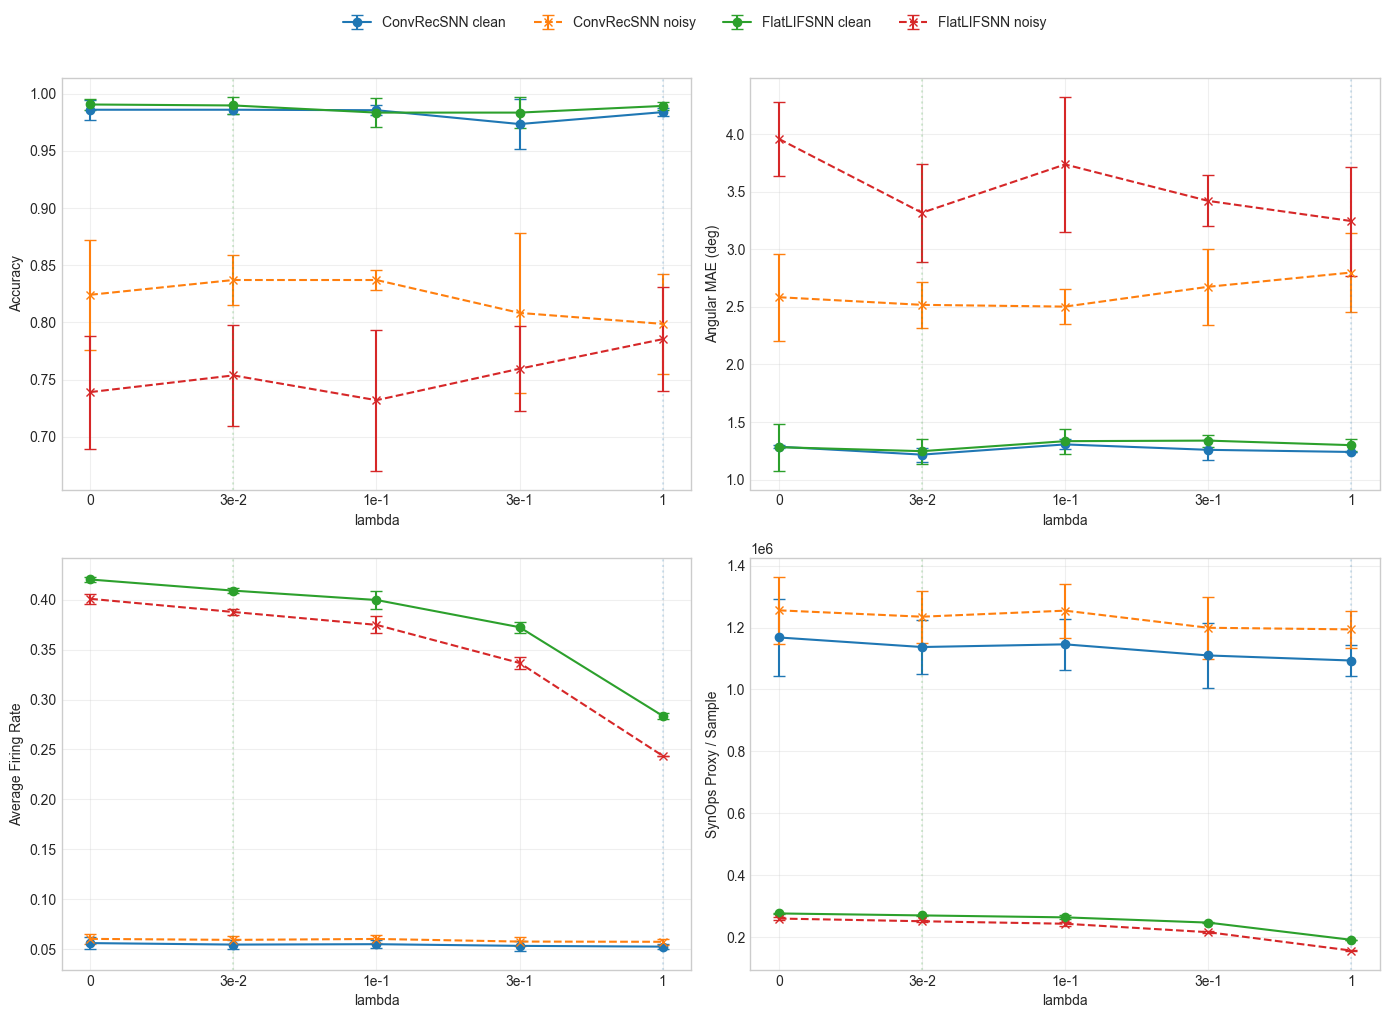

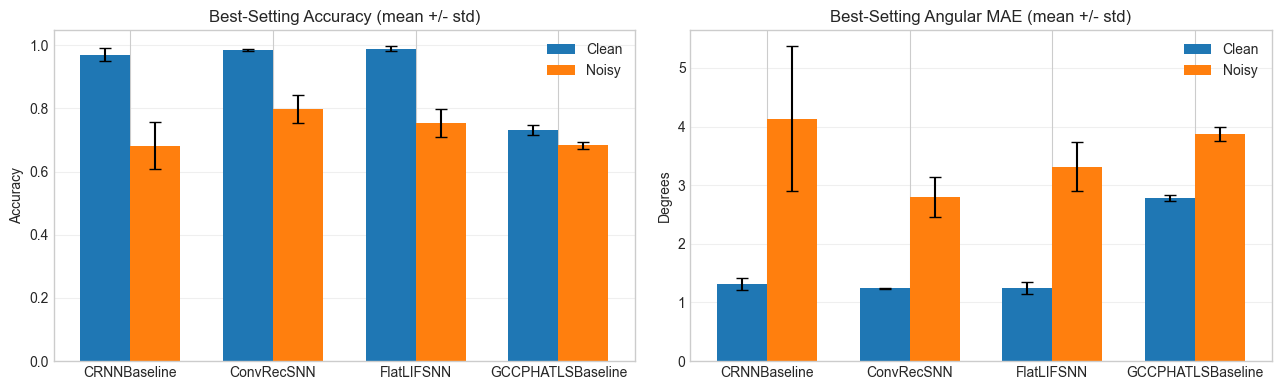

In [62]:
df_snn = summary_agg_df[summary_agg_df["family"] == "snn"].copy()
best_lambda_map = best_settings_df.set_index("model")["lambda"].to_dict()

lambda_order = [0.0, 3e-2, 1e-1, 3e-1, 1.0]
x_map = {v: i for i, v in enumerate(lambda_order)}
x_ticks = list(x_map.values())
x_labels = ["0", "3e-2", "1e-1", "3e-1", "1"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_specs = [
    ("acc_mean", "acc_std", "Accuracy"),
    ("ang_mae_deg_mean", "ang_mae_deg_std", "Angular MAE (deg)"),
    ("fr_mean", "fr_std", "Average Firing Rate"),
    ("synops_per_sample_mean", "synops_per_sample_std", "SynOps Proxy / Sample"),
]

for ax, (mean_col, std_col, ylabel) in zip(axes.flat, plot_specs):
    for model_name, group in df_snn.groupby("model"):
        clean = group[group["split"] == "clean"].sort_values("lambda")
        noisy = group[group["split"] == "noisy"].sort_values("lambda")

        clean_x = clean["lambda"].map(x_map)
        noisy_x = noisy["lambda"].map(x_map)

        clean_line = ax.errorbar(
            clean_x,
            clean[mean_col],
            yerr=clean[std_col],
            marker="o",
            capsize=4,
            label=f"{model_name} clean",
        )
        ax.errorbar(
            noisy_x,
            noisy[mean_col],
            yerr=noisy[std_col],
            marker="x",
            linestyle="--",
            capsize=4,
            label=f"{model_name} noisy",
        )

        best_lambda = best_lambda_map.get(model_name)
        if best_lambda is not None and best_lambda in x_map and best_lambda > 0:
            ax.axvline(
                x_map[best_lambda],
                color=clean_line.lines[0].get_color(),
                linestyle=":",
                alpha=0.2,
            )

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.set_xlim(-0.2, len(lambda_order) - 0.8)
    ax.set_xlabel("lambda")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

compare_df = best_df.copy()
models = compare_df["model"].drop_duplicates().tolist()
x = np.arange(len(models))
width = 0.35

acc_mean, acc_std = split_metric_arrays(compare_df, models, "acc")
mae_mean, mae_std = split_metric_arrays(compare_df, models, "ang_mae_deg")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, mean_map, std_map, ylabel, title in [
    (axes[0], acc_mean, acc_std, "Accuracy", "Best-Setting Accuracy (mean +/- std)"),
    (axes[1], mae_mean, mae_std, "Degrees", "Best-Setting Angular MAE (mean +/- std)"),
]:
    ax.bar(x - width / 2, mean_map["clean"], width, yerr=std_map["clean"], capsize=4, label="Clean")
    ax.bar(x + width / 2, mean_map["noisy"], width, yerr=std_map["noisy"], capsize=4, label="Noisy")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=0)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

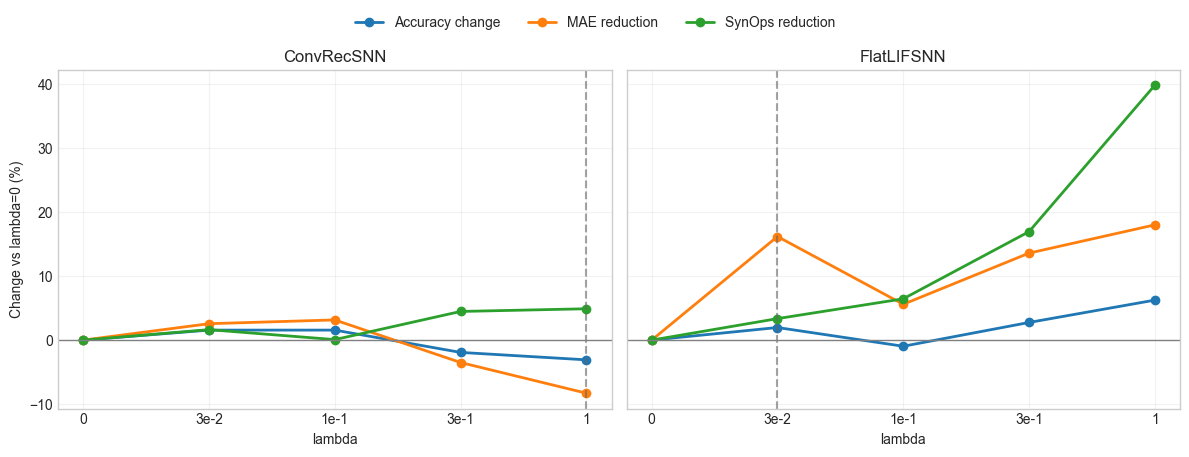

In [ ]:
lambda_order = [0.0, 3e-2, 1e-1, 3e-1, 1.0]
lambda_labels = ["0", "3e-2", "1e-1", "3e-1", "1"]
x_map = {v: i for i, v in enumerate(lambda_order)}

model_order = [m for m in ["ConvRecSNN", "FlatLIFSNN"] if m in tradeoff_df["model"].unique()]
best_lambda_map = best_settings_df.set_index("model")["lambda"].to_dict()

metric_specs = [
    ("acc_change_pct", "Accuracy change"),
    ("mae_reduction_pct", "MAE reduction"),
    ("synops_reduction_pct", "SynOps reduction"),
]

fig, axes = plt.subplots(1, len(model_order), figsize=(6 * len(model_order), 4.5), sharey=True)
if len(model_order) == 1:
    axes = [axes]

for ax, model_name in zip(axes, model_order):
    group = tradeoff_df[tradeoff_df["model"] == model_name].sort_values("lambda").copy()
    group["x"] = group["lambda"].map(x_map)

    for col, label in metric_specs:
        ax.plot(group["x"], group[col], marker="o", linewidth=2, label=label)

    best_lambda = best_lambda_map.get(model_name)
    if best_lambda is not None and best_lambda in x_map and best_lambda > 0:
        ax.axvline(x_map[best_lambda], color="0.4", linestyle="--", alpha=0.6)

    ax.axhline(0, color="0.5", linewidth=1)
    ax.set_title(model_name)
    ax.set_xticks(list(x_map.values()))
    ax.set_xticklabels(lambda_labels)
    ax.set_xlabel("lambda")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Change vs lambda=0 (%)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [24]:
out_dir = Path(cfg.output_dir)
ensure_dir(out_dir)

summary_runs_path = out_dir / "summary_runs.csv"
summary_agg_path = out_dir / "summary_agg.csv"
selection_agg_path = out_dir / "lambda_selection_agg.csv"
best_path = out_dir / "best_settings.csv"
history_path = out_dir / "history.csv"
config_path = out_dir / "config.json"
results_path = out_dir / "results.json"

summary_df.to_csv(summary_runs_path, index=False)
summary_agg_df.to_csv(summary_agg_path, index=False)
selection_agg_df.to_csv(selection_agg_path, index=False)
best_df.to_csv(best_path, index=False)
history_df.to_csv(history_path, index=False)
config_path.write_text(json.dumps(asdict(cfg), indent=2), encoding="utf-8")
results_path.write_text(json.dumps(results, indent=2, default=json_default), encoding="utf-8")

print("Saved:")
print(" -", summary_runs_path)
print(" -", summary_agg_path)
print(" -", selection_agg_path)
print(" -", best_path)
print(" -", history_path)
print(" -", config_path)
print(" -", results_path)


Saved:
 - runs\unified_doa_notebook\summary_runs.csv
 - runs\unified_doa_notebook\summary_agg.csv
 - runs\unified_doa_notebook\lambda_selection_agg.csv
 - runs\unified_doa_notebook\best_settings.csv
 - runs\unified_doa_notebook\history.csv
 - runs\unified_doa_notebook\config.json
 - runs\unified_doa_notebook\results.json
